# 🔬 Derivable Judgement — Part B
## 📊 Data Analysis & Testing Tasks
**Red & White Skill Education** | Mathematics & Advanced Statistics

---

# 🏥 Derivable Judgement: A Statistical Decision-Making Model
**Red & White Skill Education**  
**Type:** Theory + Practical | **Duration:** 6 Hours  

---
**Scenario:** You are a data analyst at a public health research organization. Using health records categorized by gender, age groups, lifestyle habits, and diseases — apply statistical techniques to derive judgements about factors affecting disease occurrence.

## 📦 Imports & Dataset Generation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import chi2_contingency, f_oneway, ttest_ind, norm
import uuid
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
n = 500

age_groups = np.random.choice(['18-25','26-35','36-45','46-60','60+'], n, p=[0.15,0.25,0.25,0.20,0.15])
age_map = {'18-25': (18,25), '26-35': (26,35), '36-45': (36,45), '46-60': (46,60), '60+': (61,80)}
age = np.array([np.random.randint(*age_map[g]) for g in age_groups])

gender = np.random.choice(['Male','Female','Other'], n, p=[0.48,0.50,0.02])
region = np.random.choice(['North','South','East','West'], n)
smoking_status = np.random.choice(['Smoker','Non-Smoker','Former Smoker'], n, p=[0.30,0.50,0.20])
exercise_frequency = np.random.choice(['Daily','Weekly','Rarely','Never'], n, p=[0.20,0.35,0.30,0.15])

bmi = np.round(np.random.normal(26.5, 4.5, n).clip(15, 45), 1)
weight = np.round(bmi * (1.70 ** 2) + np.random.normal(0, 3, n), 1)
blood_pressure = np.round(np.random.normal(120, 15, n).clip(80, 200), 1)
cholesterol_level = np.round(np.random.normal(200, 35, n).clip(120, 320), 1)
glucose_level = np.round(np.random.normal(95, 20, n).clip(60, 300), 1)

smoke_factor = (smoking_status == 'Smoker').astype(int) * 0.25
bmi_factor = (bmi > 30).astype(int) * 0.20
diabetes_prob = 0.10 + smoke_factor * 0.5 + bmi_factor + (age > 45).astype(int) * 0.15
diabetes = np.random.binomial(1, diabetes_prob.clip(0, 0.85), n).astype(bool)

bp_factor = (blood_pressure > 130).astype(int) * 0.30
hypertension_prob = 0.10 + bp_factor + (age > 45).astype(int) * 0.15
hypertension = np.random.binomial(1, hypertension_prob.clip(0, 0.85), n).astype(bool)

visit_date = pd.date_range('2023-01-01', periods=n, freq='D').to_numpy().copy()
np.random.shuffle(visit_date)

df = pd.DataFrame({
    'record_id': [str(uuid.uuid4())[:8] for _ in range(n)],
    'age_group': age_groups,
    'age': age,
    'weight': weight,
    'gender': gender,
    'region': region,
    'smoking_status': smoking_status,
    'exercise_frequency': exercise_frequency,
    'bmi': bmi,
    'blood_pressure': blood_pressure,
    'diabetes': diabetes,
    'hypertension': hypertension,
    'cholesterol_level': cholesterol_level,
    'glucose_level': glucose_level,
    'visit_date': visit_date
})

print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (500, 15)


,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
0,12344ac6,26-35,31,76.6,Female,North,Smoker,Rarely,27.3,155.0,False,False,208.0,89.5,2024-01-30
1,7d518f3f,60+,77,64.9,Female,East,Smoker,Weekly,21.8,149.3,False,True,165.7,93.2,2023-05-03
2,1bd529e6,46-60,54,80.8,Male,South,Non-Smoker,Rarely,27.4,106.4,False,False,235.7,110.5,2024-03-02
3,1929e1a6,36-45,36,84.6,Male,West,Non-Smoker,Never,31.3,109.4,False,False,148.3,107.6,2023-05-01
4,ede3301f,26-35,30,50.9,Male,West,Former Smoker,Never,18.0,127.0,False,False,215.5,97.7,2024-04-10


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   record_id           500 non-null    str           
 1   age_group           500 non-null    str           
 2   age                 500 non-null    int64         
 3   weight              500 non-null    float64       
 4   gender              500 non-null    str           
 5   region              500 non-null    str           
 6   smoking_status      500 non-null    str           
 7   exercise_frequency  500 non-null    str           
 8   bmi                 500 non-null    float64       
 9   blood_pressure      500 non-null    float64       
 10  diabetes            500 non-null    bool          
 11  hypertension        500 non-null    bool          
 12  cholesterol_level   500 non-null    float64       
 13  glucose_level       500 non-null    float64       
 14  visit

In [3]:
df.describe()

,age,weight,bmi,blood_pressure,cholesterol_level,glucose_level,visit_date
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500
mean,41.506000,77.303200,26.663800,119.138200,199.49780,94.892200,2023-09-07 12:00:00
min,18.000000,35.500000,15.000000,80.000000,120.00000,60.000000,2023-01-01 00:00:00
25%,28.000000,68.000000,23.500000,108.500000,174.10000,81.575000,2023-05-05 18:00:00
50%,39.000000,77.650000,26.800000,118.850000,201.25000,93.550000,2023-09-07 12:00:00
75%,52.000000,86.325000,29.825000,129.800000,225.22500,107.725000,2024-01-10 06:00:00
max,79.000000,114.400000,42.200000,160.300000,302.20000,156.900000,2024-05-14 00:00:00
std,16.685646,13.508142,4.506507,14.862295,34.77492,19.607189,NaN


---
## 🔬 Part B – Data Analysis & Testing Tasks

### Task 1 – Hypothesis Formulation

In [4]:
# Task 1 - Hypothesis Formulation
print('H1: H0 = Smoking has no effect on Diabetes | H1 = Smoking affects Diabetes')
print('H2: H0 = Mean BMI is equal for diabetic and non-diabetic individuals | H1 = Diabetic have higher BMI')
print('H3: H0 = Blood pressure is equal across all age groups | H1 = Blood pressure differs across age groups')


H1: H0 = Smoking has no effect on Diabetes | H1 = Smoking affects Diabetes
H2: H0 = Mean BMI is equal for diabetic and non-diabetic individuals | H1 = Diabetic have higher BMI
H3: H0 = Blood pressure is equal across all age groups | H1 = Blood pressure differs across age groups


### Task 2 – Confidence Intervals

In [5]:
# Task 2 - Confidence Intervals (95%)
from scipy.stats import norm

z = norm.ppf(0.975)  # 1.96

for col in ['age', 'weight', 'bmi', 'blood_pressure', 'cholesterol_level']:
    mean = df[col].mean()
    se = df[col].std() / len(df[col])**0.5
    lower, upper = mean - z * se, mean + z * se
    print(f'{col}: mean={mean:.2f}, 95% CI = ({lower:.2f}, {upper:.2f})')


age: mean=41.51, 95% CI = (40.04, 42.97)
weight: mean=77.30, 95% CI = (76.12, 78.49)
bmi: mean=26.66, 95% CI = (26.27, 27.06)
blood_pressure: mean=119.14, 95% CI = (117.84, 120.44)
cholesterol_level: mean=199.50, 95% CI = (196.45, 202.55)


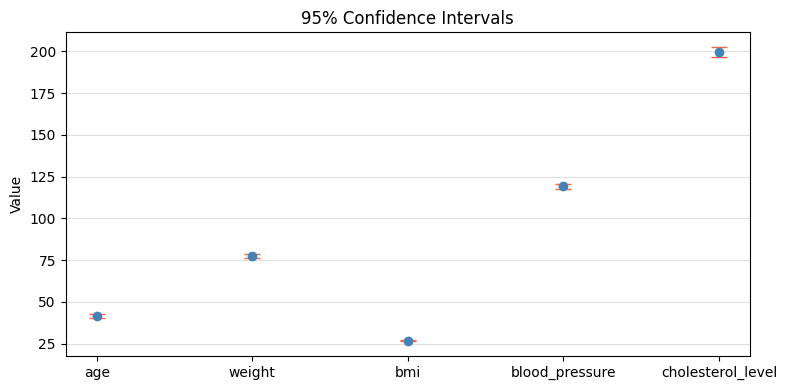

In [6]:
# CI Plot
cols = ['age', 'weight', 'bmi', 'blood_pressure', 'cholesterol_level']
means = [df[c].mean() for c in cols]
errors = [norm.ppf(0.975) * df[c].std() / len(df[c])**0.5 for c in cols]

plt.figure(figsize=(8, 4))
plt.errorbar(cols, means, yerr=errors, fmt='o', capsize=6, color='steelblue', ecolor='tomato')
plt.title('95% Confidence Intervals')
plt.ylabel('Value')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


### Task 3 – Critical Values & P-Values (Preview)

In [7]:
# Task 3 - Critical Values at alpha = 0.05
from scipy import stats

print('Z critical  :', round(stats.norm.ppf(0.975), 4))
print('T critical  :', round(stats.t.ppf(0.975, df=498), 4))
print('Chi2 critical:', round(stats.chi2.ppf(0.95, df=2), 4))
print('F critical  :', round(stats.f.ppf(0.95, dfn=4, dfd=495), 4))


Z critical  : 1.96
T critical  : 1.9647
Chi2 critical: 5.9915
F critical  : 2.3899


### Task 4 – Z-Test and T-Test (BMI: Diabetic vs Non-Diabetic)

In [8]:
# Task 4 - Z-Test and T-Test (BMI: Diabetic vs Non-Diabetic)
from scipy.stats import ttest_ind, norm

d = df[df['diabetes'] == True]['bmi']
nd = df[df['diabetes'] == False]['bmi']

# Z-Test (manual)
z_stat = (d.mean() - nd.mean()) / ((d.std()**2/len(d) + nd.std()**2/len(nd))**0.5)
z_pval = 2 * (1 - norm.cdf(abs(z_stat)))
print('Z-Test: stat =', round(z_stat, 4), ', p-value =', round(z_pval, 6))
print('Result:', 'REJECT H0' if z_pval < 0.05 else 'FAIL TO REJECT H0')
print()

# T-Test (scipy)
t_stat, t_pval = ttest_ind(d, nd)
print('T-Test: stat =', round(t_stat, 4), ', p-value =', round(t_pval, 6))
print('Result:', 'REJECT H0' if t_pval < 0.05 else 'FAIL TO REJECT H0')


Z-Test: stat = 2.798 , p-value = 0.005142
Result: REJECT H0



T-Test: stat = 3.0954 , p-value = 0.002076
Result: REJECT H0


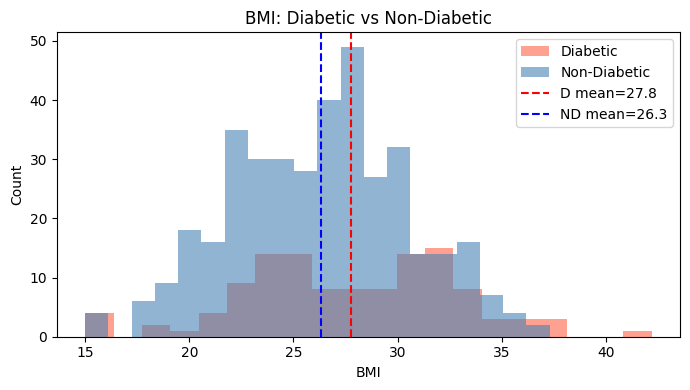

In [9]:
# BMI distribution plot
plt.figure(figsize=(7, 4))
plt.hist(d, bins=20, alpha=0.6, color='tomato', label='Diabetic')
plt.hist(nd, bins=20, alpha=0.6, color='steelblue', label='Non-Diabetic')
plt.axvline(d.mean(), color='red', linestyle='--', label=f'D mean={d.mean():.1f}')
plt.axvline(nd.mean(), color='blue', linestyle='--', label=f'ND mean={nd.mean():.1f}')
plt.title('BMI: Diabetic vs Non-Diabetic')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


### Task 5 – Chi-Square Test (Smoking vs Diabetes)

In [10]:
# Task 5 - Chi-Square Test (Smoking vs Diabetes)
from scipy.stats import chi2_contingency

ct = pd.crosstab(df['smoking_status'], df['diabetes'])
print(ct)
print()

chi2, p, dof, expected = chi2_contingency(ct)
print('Chi2 stat =', round(chi2, 4), ', p-value =', round(p, 6), ', dof =', dof)
print('Result:', 'REJECT H0 - Smoking and Diabetes are associated' if p < 0.05 else 'FAIL TO REJECT H0')


diabetes        False  True 
smoking_status              
Former Smoker      64     22
Non-Smoker        192     59
Smoker            125     38

Chi2 stat = 0.1838 , p-value = 0.912208 , dof = 2
Result: FAIL TO REJECT H0


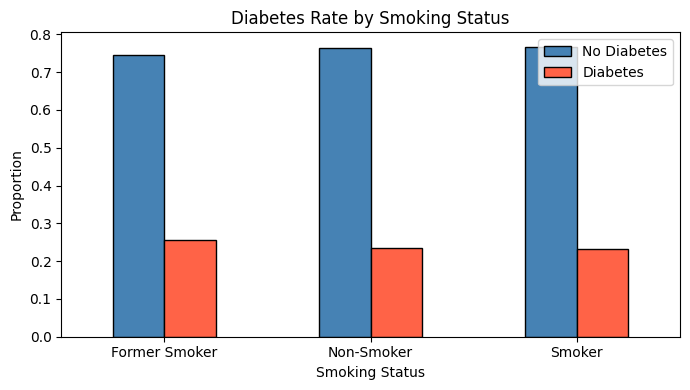

In [11]:
# Smoking vs Diabetes bar chart
ct_norm = ct.div(ct.sum(axis=1), axis=0)
ct_norm.columns = ['No Diabetes', 'Diabetes']
ct_norm.plot(kind='bar', figsize=(7, 4), color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Diabetes Rate by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()


### Task 6 – One-Way ANOVA (Blood Pressure across Age Groups)

In [12]:
# Task 6 - One-Way ANOVA (Blood Pressure across Age Groups)
from scipy.stats import f_oneway

age_labels = ['18-25', '26-35', '36-45', '46-60', '60+']
groups = [df[df['age_group'] == g]['blood_pressure'].values for g in age_labels]

for label, g in zip(age_labels, groups):
    print(f'{label}: mean = {g.mean():.2f}')

f_stat, p_anova = f_oneway(*groups)
print()
print('F stat =', round(f_stat, 4), ', p-value =', round(p_anova, 6))
print('Result:', 'REJECT H0 - Groups differ significantly' if p_anova < 0.05 else 'FAIL TO REJECT H0')


18-25: mean = 120.06
26-35: mean = 120.30
36-45: mean = 116.89
46-60: mean = 118.09
60+: mean = 120.88

F stat = 1.3526 , p-value = 0.249382
Result: FAIL TO REJECT H0


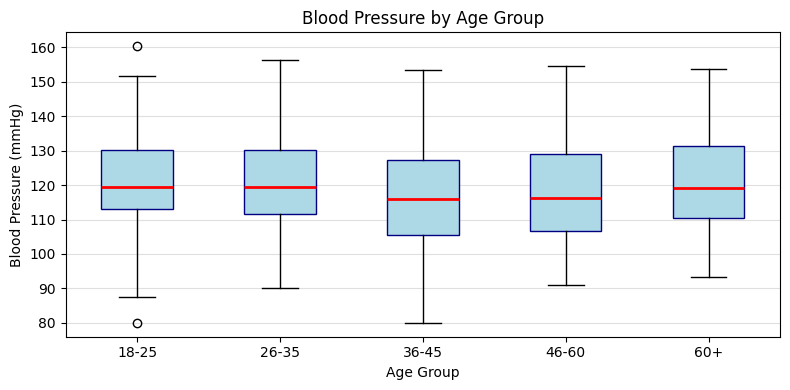

In [13]:
# ANOVA Boxplot
plt.figure(figsize=(8, 4))
plt.boxplot(groups, labels=age_labels, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='navy'),
            medianprops=dict(color='red', linewidth=2))
plt.title('Blood Pressure by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Blood Pressure (mmHg)')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


### Task 7 – Covariance and Correlation (Age vs BMI)

In [14]:
# Task 7 - Covariance and Correlation (Age vs BMI)
from scipy.stats import pearsonr

x, y = df['age'].values, df['bmi'].values

# Manual
cov = np.sum((x - x.mean()) * (y - y.mean())) / (len(x) - 1)
corr = cov / (x.std(ddof=1) * y.std(ddof=1))

# Scipy
r, p_corr = pearsonr(x, y)

print('Covariance (manual) :', round(cov, 4))
print('Covariance (numpy)  :', round(np.cov(x, y)[0][1], 4))
print()
print('Correlation (manual):', round(corr, 4))
print('Pearson r (scipy)   :', round(r, 4), ', p-value =', round(p_corr, 6))
print('Result:', 'Significant correlation' if p_corr < 0.05 else 'No significant correlation')


Covariance (manual) : 1.7428
Covariance (numpy)  : 1.7428

Correlation (manual): 0.0232
Pearson r (scipy)   : 0.0232 , p-value = 0.605132
Result: No significant correlation


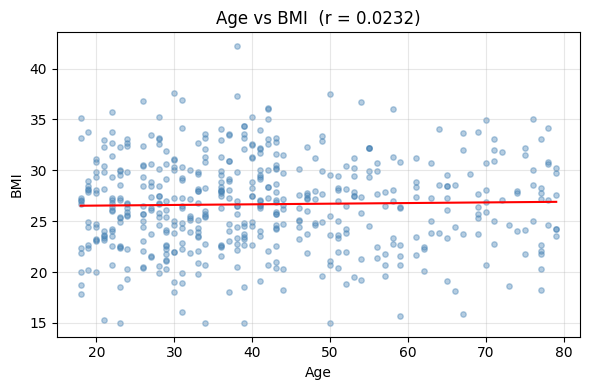

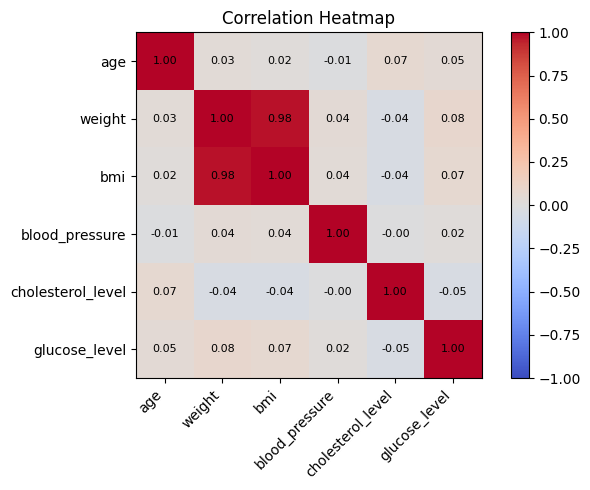

In [15]:
# Scatter plot: Age vs BMI
plt.figure(figsize=(6, 4))
plt.scatter(df['age'], df['bmi'], alpha=0.4, color='steelblue', s=15)
m, b = np.polyfit(df['age'], df['bmi'], 1)
plt.plot(sorted(df['age']), [m*xi + b for xi in sorted(df['age'])], color='red')
plt.title(f'Age vs BMI  (r = {r:.4f})')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Correlation heatmap
cols = ['age', 'weight', 'bmi', 'blood_pressure', 'cholesterol_level', 'glucose_level']
cm = df[cols].corr()
plt.figure(figsize=(7, 5))
im = plt.imshow(cm.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)
plt.xticks(range(len(cols)), cols, rotation=45, ha='right')
plt.yticks(range(len(cols)), cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j, i, f'{cm.values[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


### Task 8 – Summary of All Results

In [16]:
# Task 8 - Final Summary
print(f"{'Test':<30} {'Stat':>8} {'P-Value':>10} {'Decision':>20}")
print('-' * 72)
print(f"{'Z-Test (BMI)':<30} {z_stat:>8.4f} {z_pval:>10.6f} {'REJECT H0' if z_pval < 0.05 else 'FAIL TO REJECT':>20}")
print(f"{'T-Test (BMI)':<30} {t_stat:>8.4f} {t_pval:>10.6f} {'REJECT H0' if t_pval < 0.05 else 'FAIL TO REJECT':>20}")
print(f"{'Chi-Square (Smoking-Diabetes)':<30} {chi2:>8.4f} {p:>10.6f} {'REJECT H0' if p < 0.05 else 'FAIL TO REJECT':>20}")
print(f"{'ANOVA (BP across Age Groups)':<30} {f_stat:>8.4f} {p_anova:>10.6f} {'REJECT H0' if p_anova < 0.05 else 'FAIL TO REJECT':>20}")
print(f"{'Pearson r (Age vs BMI)':<30} {r:>8.4f} {p_corr:>10.6f} {'Significant' if p_corr < 0.05 else 'Not Significant':>20}")


Test                               Stat    P-Value             Decision
------------------------------------------------------------------------
Z-Test (BMI)                     2.7980   0.005142            REJECT H0
T-Test (BMI)                     3.0954   0.002076            REJECT H0
Chi-Square (Smoking-Diabetes)    0.1838   0.912208       FAIL TO REJECT
ANOVA (BP across Age Groups)     1.3526   0.249382       FAIL TO REJECT
Pearson r (Age vs BMI)           0.0232   0.605132      Not Significant
